# Análisis exploratorio de COVID-19 en Estados Unidos

## Objetivo

Analizar la evolución de la pandemia en Estados Unidos, evaluar la calidad de los datos e identificar los estados y periodos con mayor impacto.

## 1. Carga de librerías y datos

Importamos las librerías necesarias y cargamos el archivo CSV con los datos históricos de COVID-19.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "all-states-history.csv"
DATA_URL = "https://covidtracking.com/data/download/all-states-history.csv"

if not DATA_PATH.exists():
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    respuesta = requests.get(DATA_URL, timeout=30)
    respuesta.raise_for_status()
    DATA_PATH.write_bytes(respuesta.content)
    print("Dataset descargado desde The COVID Tracking Project.")

df = pd.read_csv(DATA_PATH)

print(f"Archivo: {DATA_PATH}")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

Archivo: C:\Users\migue\Documents\EDA\data\raw\all-states-history.csv
Filas: 20780
Columnas: 41


,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305.0,NaN,0,NaN,1293.0,1293.0,33.0,0,...,1731628.0,0,NaN,NaN,NaN,NaN,NaN,0,1731628.0,0
1,2021-03-07,AL,10148.0,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347,NaN,NaN,119757.0,NaN,2323788.0,2347,NaN,0
2,2021-03-07,AR,5319.0,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380,NaN,NaN,NaN,481311.0,NaN,0,2736442.0,3380
3,2021-03-07,AS,0.0,NaN,0,NaN,NaN,NaN,NaN,0,...,2140.0,0,NaN,NaN,NaN,NaN,NaN,0,2140.0,0
4,2021-03-07,AZ,16328.0,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110,580569.0,NaN,444089.0,NaN,3842945.0,14856,7908105.0,45110


## 2. Comprensión inicial del dataset

Antes de limpiar los datos, revisamos su estructura, tipos de variables, periodo temporal, estados incluidos y posibles duplicados.

In [3]:
print(f"Dimensiones: {df.shape}")
print(f"Fecha mínima: {df['date'].min()}")
print(f"Fecha máxima: {df['date'].max()}")
print(f"Estados y territorios: {df['state'].nunique()}")
print(f"Duplicados completos: {df.duplicated().sum()}")

df.info()

Dimensiones: (20780, 41)
Fecha mínima: 2020-01-13
Fecha máxima: 2021-03-07
Estados y territorios: 56
Duplicados completos: 0
<class 'pandas.DataFrame'>
RangeIndex: 20780 entries, 0 to 20779
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              20780 non-null  str    
 1   state                             20780 non-null  str    
 2   death                             19930 non-null  float64
 3   deathConfirmed                    9422 non-null   float64
 4   deathIncrease                     20780 non-null  int64  
 5   deathProbable                     7593 non-null   float64
 6   hospitalized                      12382 non-null  float64
 7   hospitalizedCumulative            12382 non-null  float64
 8   hospitalizedCurrently             17339 non-null  float64
 9   hospitalizedIncrease              20780 non-null  int64  
 10  inIcuCumulative 

### Observaciones iniciales

- El dataset contiene 20.780 registros y 41 variables.
- Comprende el periodo entre el 13 de enero de 2020 y el 7 de marzo de 2021.
- Incluye 56 estados y territorios.
- No se encontraron filas completamente duplicadas.
- La columna `date` está almacenada como texto y deberá convertirse a formato fecha.
- Existen numerosos valores ausentes, especialmente en las variables relacionadas con pruebas específicas, UCI y ventilación.

In [4]:
df["date"] = pd.to_datetime(df["date"])

duplicados_fecha_estado = df.duplicated(
    subset=["date", "state"]
).sum()

print(f"Tipo de date: {df['date'].dtype}")
print(f"Duplicados por fecha y estado: {duplicados_fecha_estado}")

Tipo de date: datetime64[us]
Duplicados por fecha y estado: 0


## 3. Análisis de valores ausentes

Calculamos el porcentaje de datos ausentes por columna. Esto permitirá descartar variables con una cobertura insuficiente y evitar conclusiones poco fiables.

In [5]:
valores_ausentes = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
    .to_frame(name="porcentaje_ausente")
)

valores_ausentes.head(15)

,porcentaje_ausente
positiveTestsPeopleAntigen,96.95
negativeTestsPeopleAntibody,95.32
totalTestsPeopleAntigen,95.19
positiveTestsPeopleAntibody,94.74
onVentilatorCumulative,93.79
negativeTestsAntibody,92.98
totalTestsPeopleAntibody,89.41
positiveTestsAntigen,89.25
positiveTestsAntibody,83.90
totalTestsAntigen,83.54


### Interpretación

Las variables con mayor ausencia corresponden principalmente a pruebas de antígenos y anticuerpos, datos acumulados de ventilación y registros acumulados de UCI.

Estas variables no fueron reportadas de manera homogénea por todos los estados. Por ello, no se utilizarán como indicadores principales del análisis, ya que podrían producir comparaciones incompletas o engañosas.

El análisis se centrará en variables con mayor cobertura y relevancia ejecutiva: casos positivos, fallecimientos, hospitalizaciones actuales y resultados de pruebas.

In [6]:
columnas_principales = [
    "positive",
    "positiveIncrease",
    "death",
    "deathIncrease",
    "hospitalizedCurrently",
    "inIcuCurrently",
    "onVentilatorCurrently",
    "totalTestResults",
]

cobertura_principal = (
    df[columnas_principales]
    .notna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .to_frame(name="porcentaje_disponible")
)

cobertura_principal

,porcentaje_disponible
positiveIncrease,100.00
deathIncrease,100.00
totalTestResults,99.20
positive,99.10
death,95.91
hospitalizedCurrently,83.44
inIcuCurrently,56.00
onVentilatorCurrently,43.92


### Selección de indicadores

Los casos positivos, fallecimientos y pruebas presentan una cobertura superior al 95 %, por lo que serán los indicadores principales.

Las hospitalizaciones actuales tienen una cobertura del 83,44 % y podrán analizarse indicando esta limitación.

Los datos de UCI y ventilación no se utilizarán para comparaciones generales, ya que faltan en aproximadamente la mitad de los registros.

In [7]:
columnas_incremento = [
    "positiveIncrease",
    "deathIncrease",
    "hospitalizedIncrease",
    "totalTestResultsIncrease",
]

resumen_incrementos = pd.DataFrame({
    "mínimo": df[columnas_incremento].min(),
    "máximo": df[columnas_incremento].max(),
    "valores_negativos": (df[columnas_incremento] < 0).sum(),
})

resumen_incrementos

,mínimo,máximo,valores_negativos
positiveIncrease,-7757,71734,24
deathIncrease,-201,2559,73
hospitalizedIncrease,-12257,16373,88
totalTestResultsIncrease,-130545,473076,49


### Valores negativos

Se detectaron incrementos diarios negativos en casos, fallecimientos, hospitalizaciones y pruebas.

Estos valores suelen corresponder a correcciones retrospectivas realizadas por los estados, como eliminación de duplicados o reclasificación de registros. Por tanto, no deben interpretarse como una reducción real de casos o fallecimientos.

Se conservarán los datos originales y se señalará esta limitación al interpretar las tendencias diarias.

In [8]:
correcciones_casos = (
    df.loc[df["positiveIncrease"] < 0, [
        "date",
        "state",
        "positiveIncrease",
        "positive",
    ]]
    .sort_values("positiveIncrease")
)

correcciones_casos.head(10)

,date,state,positiveIncrease,positive
10437,2020-09-02,MA,-7757,121131.0
16114,2020-05-24,PR,-640,1230.0
11426,2020-08-15,AR,-400,51992.0
17906,2020-04-22,PR,-383,915.0
9171,2020-09-25,RI,-130,24181.0
14636,2020-06-19,LA,-119,48515.0
17794,2020-04-24,PR,-44,871.0
12609,2020-07-25,DE,-27,14175.0
15911,2020-05-27,CT,-15,41288.0
11263,2020-08-18,CT,-12,51255.0


## 4. Selección y preparación de variables

Seleccionamos los indicadores más relevantes y comprobamos qué estados y territorios forman parte del dataset.

In [9]:
estados_disponibles = sorted(df["state"].unique())

print(f"Total: {len(estados_disponibles)}")
print(estados_disponibles)

Total: 56
['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'GU', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MP', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VI', 'VT', 'WA', 'WI', 'WV', 'WY']


### Cobertura geográfica

El dataset contiene 56 jurisdicciones: los 50 estados, Washington D. C. y cinco territorios estadounidenses.

Para los análisis nacionales se utilizarán todas las jurisdicciones. En las comparaciones entre estados se indicará expresamente si se incluyen o excluyen los territorios.

In [10]:
columnas_analisis = [
    "date",
    "state",
    "positive",
    "positiveIncrease",
    "death",
    "deathIncrease",
    "hospitalizedCurrently",
    "totalTestResults",
    "totalTestResultsIncrease",
]

df_clean = (
    df[columnas_analisis]
    .copy()
    .sort_values(["state", "date"])
    .reset_index(drop=True)
)

print(f"Dimensiones originales: {df.shape}")
print(f"Dimensiones para el análisis: {df_clean.shape}")

df_clean.head()

Dimensiones originales: (20780, 41)
Dimensiones para el análisis: (20780, 9)


,date,state,positive,positiveIncrease,death,deathIncrease,hospitalizedCurrently,totalTestResults,totalTestResultsIncrease
0,2020-03-06,AK,NaN,0,0.0,0,NaN,8.0,0
1,2020-03-07,AK,NaN,0,0.0,0,NaN,12.0,4
2,2020-03-08,AK,NaN,0,0.0,0,NaN,14.0,2
3,2020-03-09,AK,NaN,0,0.0,0,NaN,23.0,9
4,2020-03-10,AK,NaN,0,0.0,0,NaN,23.0,0


## 5. Evolución nacional de la pandemia

Agrupamos los registros por fecha para estudiar la evolución diaria de casos, fallecimientos y pruebas en Estados Unidos.

Se conservan las correcciones negativas del dataset original y se utiliza una media móvil de siete días para reducir las fluctuaciones diarias.

In [11]:
evolucion_nacional = (
    df_clean.groupby("date", as_index=False)
    .agg(
        nuevos_casos=("positiveIncrease", "sum"),
        nuevos_fallecimientos=("deathIncrease", "sum"),
        nuevas_pruebas=("totalTestResultsIncrease", "sum"),
        hospitalizados=("hospitalizedCurrently", "sum"),
    )
    .sort_values("date")
)

evolucion_nacional["media_7d_casos"] = (
    evolucion_nacional["nuevos_casos"]
    .rolling(window=7, min_periods=1)
    .mean()
)

evolucion_nacional["media_7d_fallecimientos"] = (
    evolucion_nacional["nuevos_fallecimientos"]
    .rolling(window=7, min_periods=1)
    .mean()
)

evolucion_nacional.head()

,date,nuevos_casos,nuevos_fallecimientos,nuevas_pruebas,hospitalizados,media_7d_casos,media_7d_fallecimientos
0,2020-01-13,0,0,0,0.0,0.0,0.0
1,2020-01-14,0,0,0,0.0,0.0,0.0
2,2020-01-15,0,0,0,0.0,0.0,0.0
3,2020-01-16,0,0,0,0.0,0.0,0.0
4,2020-01-17,0,0,0,0.0,0.0,0.0


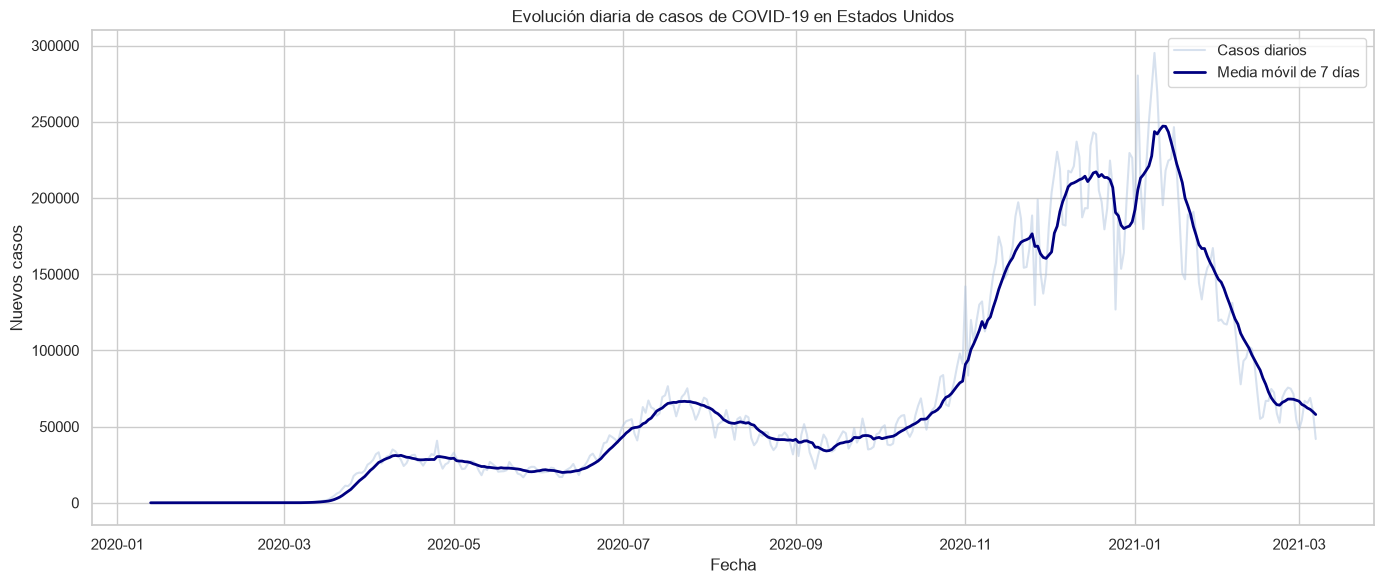

In [12]:
sns.set_theme(style="whitegrid")

FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    evolucion_nacional["date"],
    evolucion_nacional["nuevos_casos"],
    color="lightsteelblue",
    alpha=0.5,
    label="Casos diarios",
)

ax.plot(
    evolucion_nacional["date"],
    evolucion_nacional["media_7d_casos"],
    color="navy",
    linewidth=2,
    label="Media móvil de 7 días",
)

ax.set_title("Evolución diaria de casos de COVID-19 en Estados Unidos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Nuevos casos")
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "evolucion_casos_usa.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [13]:
pico_casos = evolucion_nacional.loc[
    evolucion_nacional["media_7d_casos"].idxmax()
]

print(f"Fecha del pico: {pico_casos['date']:%d/%m/%Y}")
print(f"Media de casos diarios: {pico_casos['media_7d_casos']:,.0f}")

Fecha del pico: 11/01/2021
Media de casos diarios: 247,111


### Hallazgo principal

La mayor ola de contagios se produjo durante el invierno de 2020-2021. El máximo de la media móvil de siete días se alcanzó el 11 de enero de 2021, con aproximadamente 247.111 nuevos casos diarios.

La media móvil permite observar mejor la tendencia al reducir las variaciones provocadas por retrasos y diferencias en la notificación diaria.

### Evolución de los fallecimientos

Analizamos los fallecimientos diarios mediante una media móvil de siete días para identificar la etapa más crítica de la pandemia.

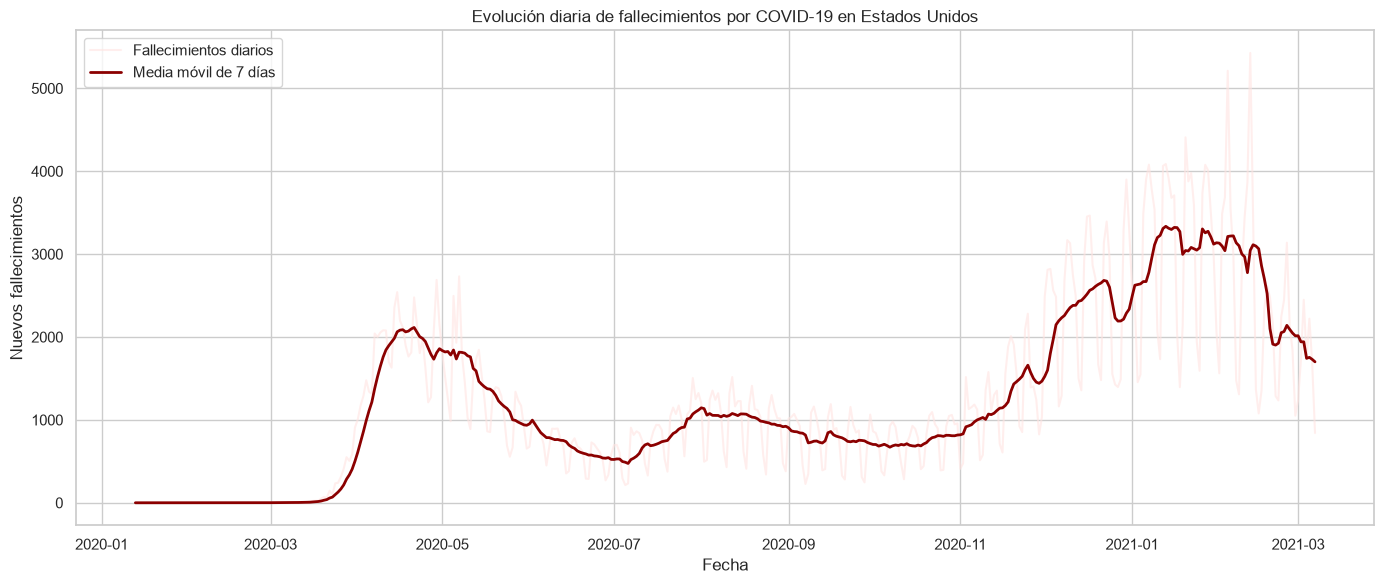

Fecha del pico: 13/01/2021
Media de fallecimientos diarios: 3,335


In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    evolucion_nacional["date"],
    evolucion_nacional["nuevos_fallecimientos"],
    color="mistyrose",
    alpha=0.6,
    label="Fallecimientos diarios",
)

ax.plot(
    evolucion_nacional["date"],
    evolucion_nacional["media_7d_fallecimientos"],
    color="darkred",
    linewidth=2,
    label="Media móvil de 7 días",
)

ax.set_title("Evolución diaria de fallecimientos por COVID-19 en Estados Unidos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Nuevos fallecimientos")
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "evolucion_fallecimientos_usa.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

pico_fallecimientos = evolucion_nacional.loc[
    evolucion_nacional["media_7d_fallecimientos"].idxmax()
]

print(f"Fecha del pico: {pico_fallecimientos['date']:%d/%m/%Y}")
print(
    "Media de fallecimientos diarios: "
    f"{pico_fallecimientos['media_7d_fallecimientos']:,.0f}"
)

### Hallazgo principal

La media móvil alcanzó su máximo el 13 de enero de 2021, con aproximadamente 3.335 fallecimientos diarios.

El máximo registrado coincide con la gran ola del invierno de 2020-2021. Aunque aparece dos días después del pico estadístico de casos, esta diferencia no representa el tiempo clínico entre contagio y fallecimiento, ya que los datos están condicionados por retrasos y correcciones en la notificación.

## 6. Comparación entre estados

Comparamos los casos acumulados al final del periodo. Se excluyen los cinco territorios, pero se mantiene Washington D. C.

Estos valores reflejan el volumen total registrado y no el impacto proporcional sobre la población.

In [15]:
territorios = ["AS", "GU", "MP", "PR", "VI"]

ultimo_registro = (
    df_clean.loc[~df_clean["state"].isin(territorios)]
    .sort_values("date")
    .groupby("state", as_index=False)
    .tail(1)
)

top_casos = (
    ultimo_registro.nlargest(10, "positive")
    [["state", "positive"]]
    .sort_values("positive")
)

top_casos

,state,positive
1825,AZ,826454.0
11455,NC,872176.0
15549,PA,948643.0
14444,OH,978471.0
4444,GA,1023487.0
6272,IL,1198335.0
14076,NY,1681169.0
4075,FL,1909209.0
17751,TX,2686818.0
2194,CA,3501394.0


### Estados con más casos acumulados

California, Texas y Florida encabezan el número absoluto de casos registrados. Sin embargo, esta comparación no está ajustada por población, por lo que representa el volumen total y no el riesgo individual.

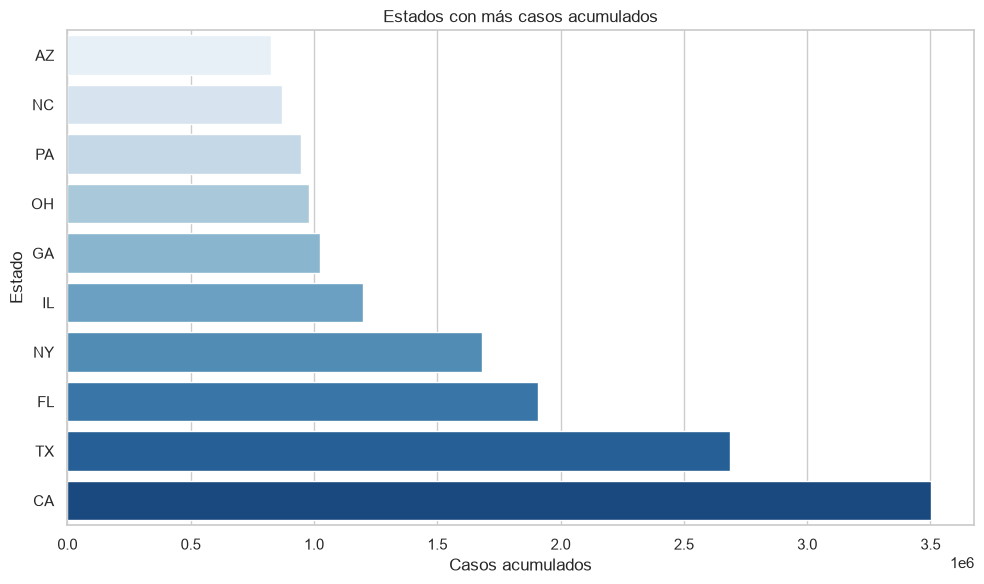

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_casos,
    x="positive",
    y="state",
    hue="state",
    palette="Blues",
    legend=False,
    ax=ax,
)

ax.set_title("Estados con más casos acumulados")
ax.set_xlabel("Casos acumulados")
ax.set_ylabel("Estado")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "top_10_estados_casos.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Estados con más fallecimientos acumulados

Se comparan los fallecimientos totales registrados hasta el final del periodo. Al igual que con los casos, son valores absolutos sin ajustar por población.

In [17]:
top_fallecimientos = (
    ultimo_registro.nlargest(10, "death")
    [["state", "death"]]
    .sort_values("death")
)

top_fallecimientos

,state,death
9264,MI,16658.0
14444,OH,17656.0
4444,GA,17906.0
6272,IL,23014.0
12969,NJ,23574.0
15549,PA,24349.0
4075,FL,32266.0
14076,NY,39029.0
17751,TX,44451.0
2194,CA,54124.0


### Interpretación

California y Texas encabezan tanto los casos como los fallecimientos acumulados. Nueva York ocupa el tercer lugar en fallecimientos pese a situarse por detrás de Florida en casos.

Esto podría estar relacionado con el fuerte impacto sufrido por Nueva York durante la primera ola, aunque para comparar la gravedad entre estados sería necesario ajustar los datos por población y considerar diferencias temporales y de notificación.

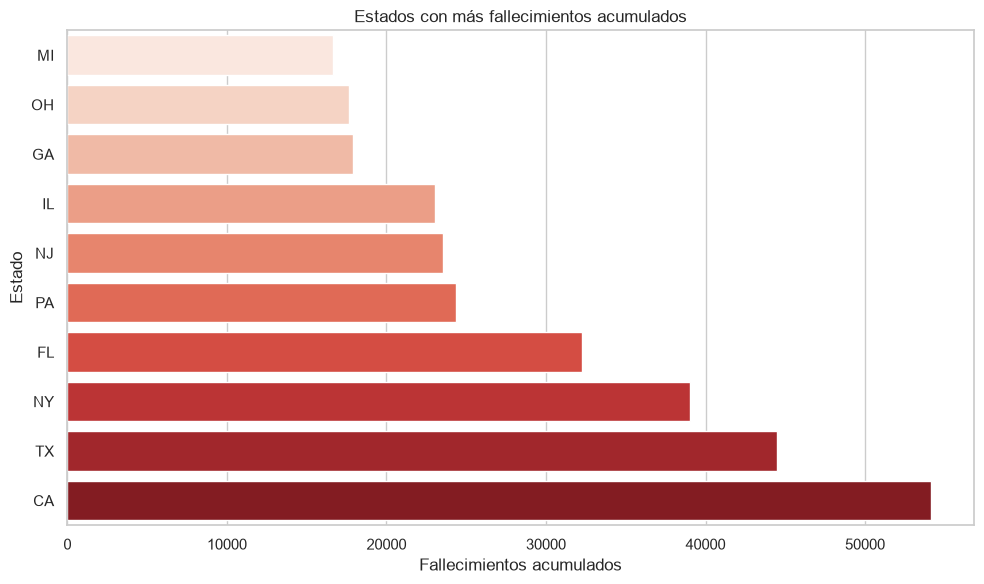

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_fallecimientos,
    x="death",
    y="state",
    hue="state",
    palette="Reds",
    legend=False,
    ax=ax,
)

ax.set_title("Estados con más fallecimientos acumulados")
ax.set_xlabel("Fallecimientos acumulados")
ax.set_ylabel("Estado")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "top_10_estados_fallecimientos.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 7. Exportación del dataset limpio

Guardamos una versión procesada con las variables seleccionadas, fechas corregidas, registros ordenados y una marca para identificar correcciones administrativas negativas.

In [19]:
df_clean["tiene_correccion_negativa"] = (
    (df_clean["positiveIncrease"] < 0)
    | (df_clean["deathIncrease"] < 0)
    | (df_clean["totalTestResultsIncrease"] < 0)
)

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = PROCESSED_PATH / "covid19_usa_clean.csv"

df_clean.to_csv(OUTPUT_FILE, index=False)

print(f"Archivo guardado en: {OUTPUT_FILE}")
print(f"Filas: {len(df_clean)}")
print(f"Columnas: {len(df_clean.columns)}")
print(
    "Registros con correcciones negativas: "
    f"{df_clean['tiene_correccion_negativa'].sum()}"
)

Archivo guardado en: C:\Users\migue\Documents\EDA\data\processed\covid19_usa_clean.csv
Filas: 20780
Columnas: 10
Registros con correcciones negativas: 141


### Resultado del procesamiento

El dataset procesado conserva los 20.780 registros originales y reduce las variables de 41 a 10 indicadores relevantes.

Se añadió la variable `tiene_correccion_negativa`, que identifica 141 registros afectados por revisiones administrativas. Los valores originales se mantienen para garantizar la trazabilidad de los datos.

## 8. Evolución de las hospitalizaciones

Los datos de hospitalización tienen menor cobertura que los casos y fallecimientos. Por ello, junto al total diario se calcula cuántas jurisdicciones comunicaron información.

In [20]:
hospitalizaciones = (
    df_clean.groupby("date", as_index=False)
    .agg(
        hospitalizados=(
            "hospitalizedCurrently",
            lambda serie: serie.sum(min_count=1),
        ),
        jurisdicciones_reportando=(
            "hospitalizedCurrently",
            "count",
        ),
    )
    .sort_values("date")
)

pico_hospitalizaciones = hospitalizaciones.loc[
    hospitalizaciones["hospitalizados"].idxmax()
]

print(
    f"Fecha del máximo: "
    f"{pico_hospitalizaciones['date']:%d/%m/%Y}"
)
print(
    f"Personas hospitalizadas: "
    f"{pico_hospitalizaciones['hospitalizados']:,.0f}"
)
print(
    f"Jurisdicciones reportando: "
    f"{pico_hospitalizaciones['jurisdicciones_reportando']:.0f}"
)

Fecha del máximo: 06/01/2021
Personas hospitalizadas: 132,474
Jurisdicciones reportando: 53


### Hallazgo principal

La presión hospitalaria alcanzó su máximo el 6 de enero de 2021, con 132.474 personas hospitalizadas. En esa fecha reportaron información 53 de las 56 jurisdicciones, por lo que el total debe considerarse una aproximación.

El pico hospitalario se produjo durante la misma ola invernal en la que se registraron los máximos de casos y fallecimientos.

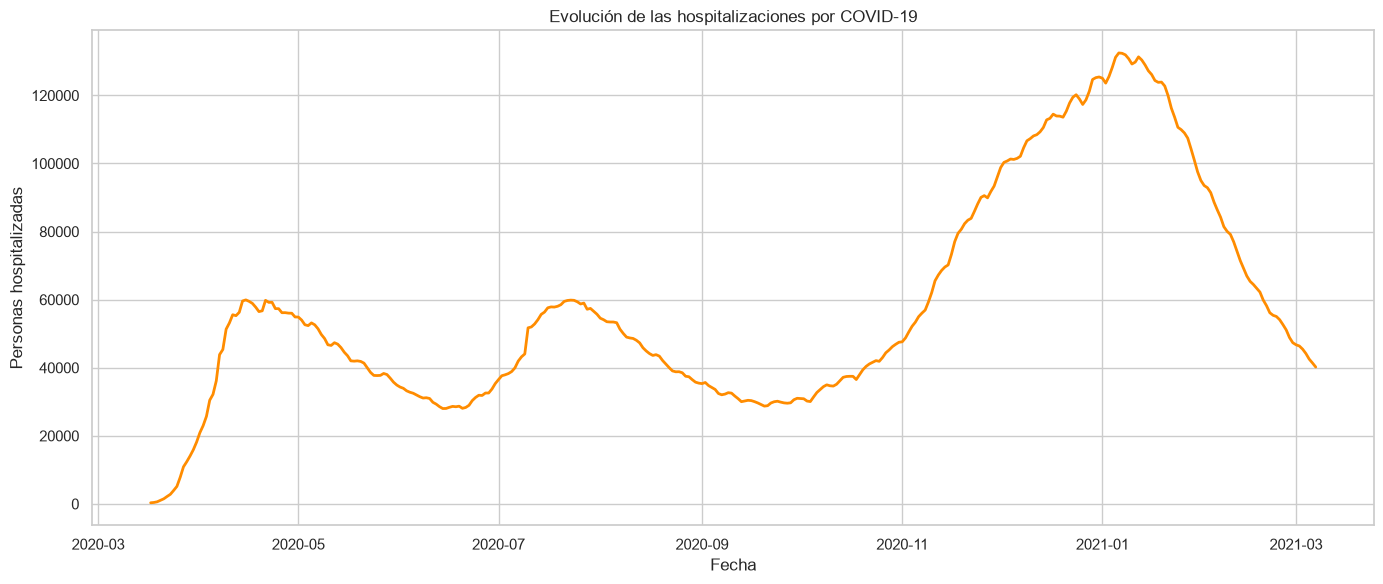

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    hospitalizaciones["date"],
    hospitalizaciones["hospitalizados"],
    color="darkorange",
    linewidth=2,
)

ax.set_title("Evolución de las hospitalizaciones por COVID-19")
ax.set_xlabel("Fecha")
ax.set_ylabel("Personas hospitalizadas")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "evolucion_hospitalizaciones_usa.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 9. Estadística descriptiva

Resumimos los indicadores nacionales diarios para conocer su tendencia central,
dispersión y valores extremos. Las variables diarias incluyen correcciones
administrativas, por lo que algunos mínimos pueden ser negativos.

In [22]:
estadistica_nacional = (
    evolucion_nacional[
        [
            "nuevos_casos",
            "nuevos_fallecimientos",
            "nuevas_pruebas",
            "hospitalizados",
        ]
    ]
    .describe()
    .T
    .rename(
        columns={
            "count": "registros",
            "mean": "media",
            "std": "desviacion",
            "min": "minimo",
            "25%": "q1",
            "50%": "mediana",
            "75%": "q3",
            "max": "maximo",
        }
    )
    .round(2)
)

estadistica_nacional

,registros,media,desviacion,minimo,q1,mediana,q3,maximo
nuevos_casos,420.0,68467.60,68682.45,0.0,22462.50,44664.5,89684.25,295121.0
nuevos_fallecimientos,420.0,1226.55,1070.13,0.0,439.75,1016.0,1642.50,5427.0
nuevas_pruebas,420.0,866248.35,657948.54,0.0,238855.75,822368.5,1401705.50,2309884.0
hospitalizados,420.0,49150.99,36019.98,0.0,30033.00,43463.0,59796.50,132474.0


### Interpretación

- La media y la mediana difieren considerablemente en casos y fallecimientos,
  lo que indica distribuciones asimétricas marcadas por las grandes olas.
- Los máximos están muy alejados del tercer cuartil y representan jornadas
  extraordinarias.
- Los mínimos negativos no son valores epidemiológicos reales, sino revisiones
  de cifras previamente comunicadas.

## 10. Análisis univariante y valores atípicos

Estudiamos por separado la distribución de casos y fallecimientos diarios.
Para visualizar la distribución epidemiológica se excluyen únicamente los
ajustes negativos del gráfico, pero no se eliminan del dataset.

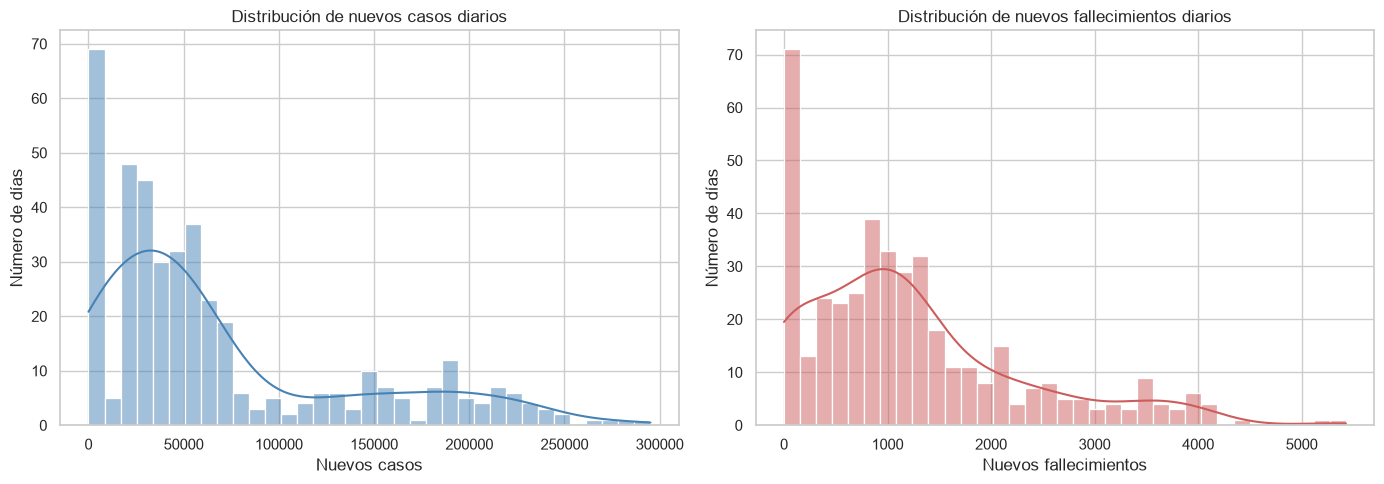

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    evolucion_nacional.loc[
        evolucion_nacional["nuevos_casos"] >= 0,
        "nuevos_casos",
    ],
    bins=35,
    kde=True,
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Distribución de nuevos casos diarios")
axes[0].set_xlabel("Nuevos casos")
axes[0].set_ylabel("Número de días")

sns.histplot(
    evolucion_nacional.loc[
        evolucion_nacional["nuevos_fallecimientos"] >= 0,
        "nuevos_fallecimientos",
    ],
    bins=35,
    kde=True,
    color="indianred",
    ax=axes[1],
)
axes[1].set_title("Distribución de nuevos fallecimientos diarios")
axes[1].set_xlabel("Nuevos fallecimientos")
axes[1].set_ylabel("Número de días")

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "distribucion_casos_fallecimientos.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [24]:
def resumen_outliers_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = serie[
        (serie < limite_inferior)
        | (serie > limite_superior)
    ]
    return pd.Series({
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "numero_outliers": len(outliers),
    })

outliers_nacionales = pd.DataFrame({
    "casos": resumen_outliers_iqr(
        evolucion_nacional["nuevos_casos"]
    ),
    "fallecimientos": resumen_outliers_iqr(
        evolucion_nacional["nuevos_fallecimientos"]
    ),
}).T.round(2)

outliers_nacionales

,q1,q3,iqr,limite_inferior,limite_superior,numero_outliers
casos,22462.50,89684.25,67221.75,-78370.12,190516.88,40.0
fallecimientos,439.75,1642.50,1202.75,-1364.38,3446.62,28.0


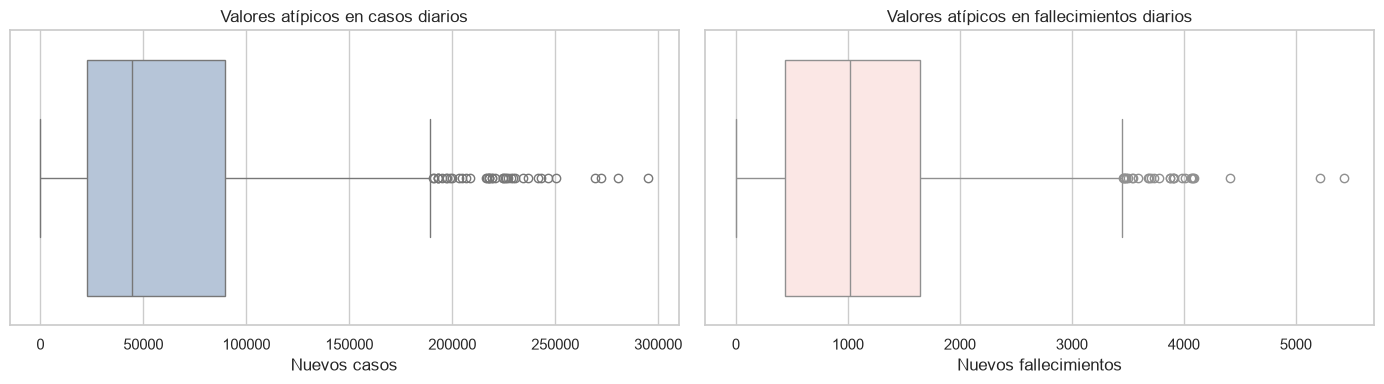

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(
    x=evolucion_nacional["nuevos_casos"],
    color="lightsteelblue",
    ax=axes[0],
)
axes[0].set_title("Valores atípicos en casos diarios")
axes[0].set_xlabel("Nuevos casos")

sns.boxplot(
    x=evolucion_nacional["nuevos_fallecimientos"],
    color="mistyrose",
    ax=axes[1],
)
axes[1].set_title("Valores atípicos en fallecimientos diarios")
axes[1].set_xlabel("Nuevos fallecimientos")

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "boxplots_incrementos_diarios.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Interpretación de los outliers

Los valores extremos coinciden principalmente con periodos de alta transmisión
y con días de acumulación o corrección de registros. No se eliminan
automáticamente porque contienen información relevante sobre la evolución y
la calidad del sistema de notificación.

## 11. Calidad y cobertura de los datos

Además del porcentaje global de valores disponibles, analizamos cómo cambió
la cobertura hospitalaria a lo largo del tiempo y qué variables presentan
mayores carencias.

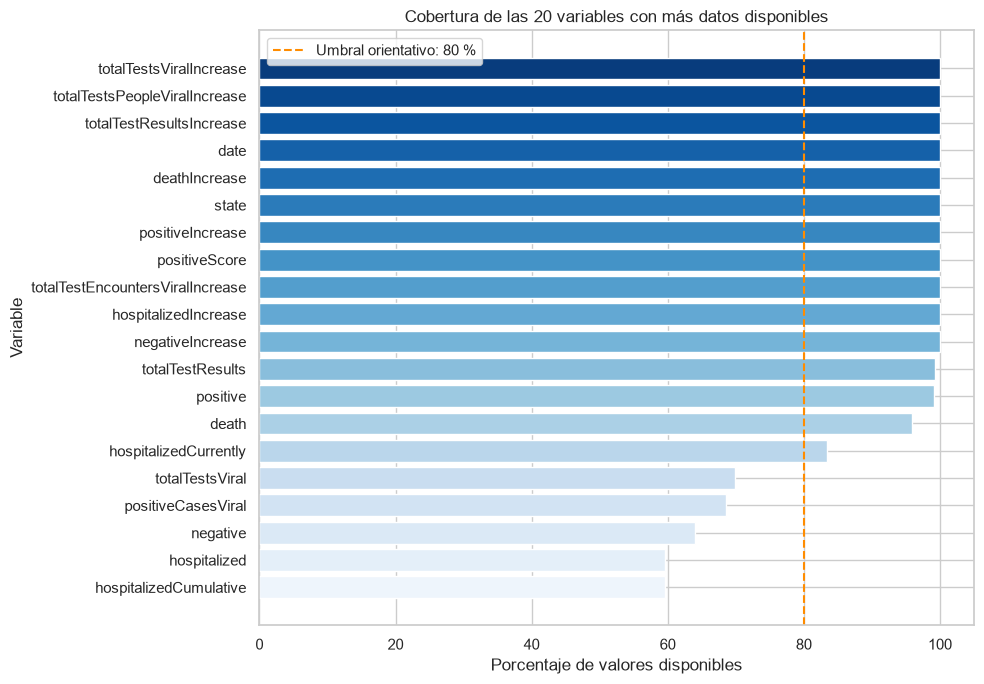

In [26]:
cobertura_columnas = (
    df.notna()
    .mean()
    .mul(100)
    .sort_values()
    .tail(20)
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    cobertura_columnas.index,
    cobertura_columnas.values,
    color=sns.color_palette("Blues", len(cobertura_columnas)),
)
ax.axvline(80, color="darkorange", linestyle="--", label="Umbral orientativo: 80 %")
ax.set_title("Cobertura de las 20 variables con más datos disponibles")
ax.set_xlabel("Porcentaje de valores disponibles")
ax.set_ylabel("Variable")
ax.legend()

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "cobertura_variables.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

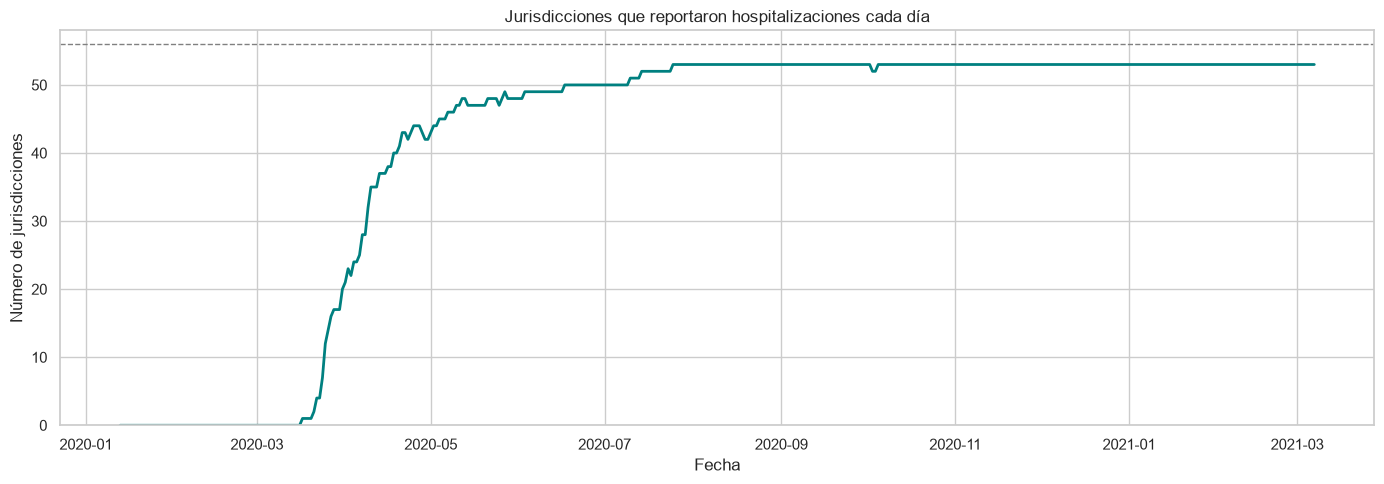

In [27]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    hospitalizaciones["date"],
    hospitalizaciones["jurisdicciones_reportando"],
    color="teal",
    linewidth=2,
)
ax.axhline(56, color="gray", linestyle="--", linewidth=1)
ax.set_title("Jurisdicciones que reportaron hospitalizaciones cada día")
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de jurisdicciones")
ax.set_ylim(0, 58)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "cobertura_hospitalizaciones_tiempo.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Hallazgo de calidad

La cobertura hospitalaria mejora con el tiempo. Los primeros registros no
representan cero hospitalizaciones, sino ausencia de información. Por ese
motivo, los días sin ninguna jurisdicción reportando se mantienen como
valores ausentes.

## 12. Evolución mensual y principales olas

La agregación mensual permite comparar periodos con menor ruido que los datos
diarios e identificar las etapas de expansión y descenso.

In [28]:
evolucion_mensual = (
    evolucion_nacional
    .assign(mes=lambda datos: datos["date"].dt.to_period("M").dt.to_timestamp())
    .groupby("mes", as_index=False)
    .agg(
        casos=("nuevos_casos", "sum"),
        fallecimientos=("nuevos_fallecimientos", "sum"),
        pruebas=("nuevas_pruebas", "sum"),
        hospitalizacion_media=("hospitalizados", "mean"),
    )
)

evolucion_mensual

,mes,casos,fallecimientos,pruebas,hospitalizacion_media
0,2020-01-01,2,0,6,0.000000
1,2020-02-01,16,5,6542,0.000000
2,2020-03-01,196851,4326,1176184,3133.612903
3,2020-04-01,876279,55315,5502666,50347.900000
4,2020-05-01,718205,41137,11513568,44385.161290
5,2020-06-01,831597,19475,16762678,30884.100000
6,2020-07-01,1900180,25249,25787479,52060.225806
7,2020-08-01,1457213,30244,25498993,44909.645161
8,2020-09-01,1192663,23329,27530527,31194.366667
9,2020-10-01,1892015,23545,36566898,37856.838710


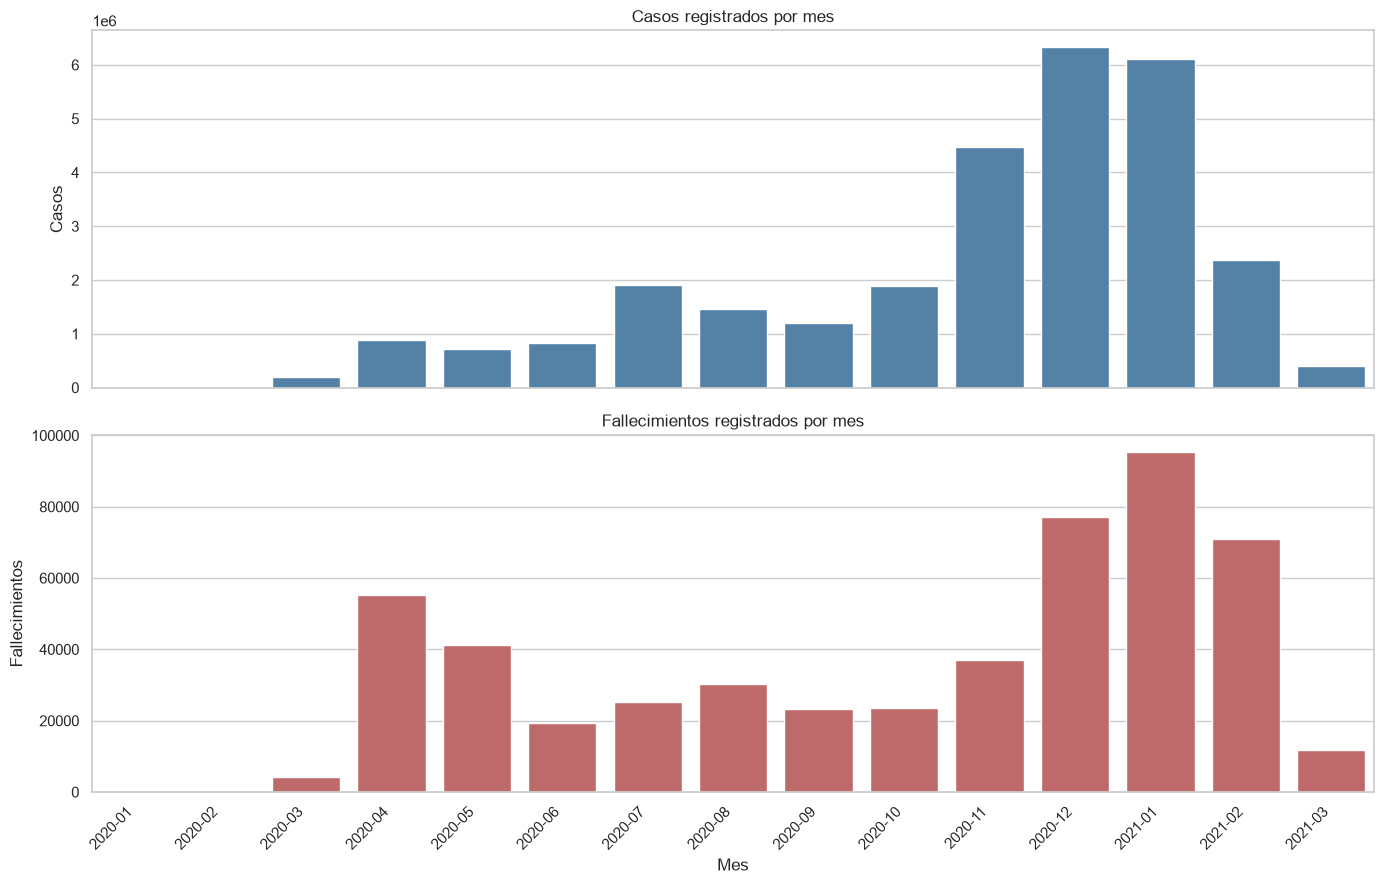

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

sns.barplot(
    data=evolucion_mensual,
    x="mes",
    y="casos",
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Casos registrados por mes")
axes[0].set_xlabel("")
axes[0].set_ylabel("Casos")

sns.barplot(
    data=evolucion_mensual,
    x="mes",
    y="fallecimientos",
    color="indianred",
    ax=axes[1],
)
axes[1].set_title("Fallecimientos registrados por mes")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Fallecimientos")

etiquetas = evolucion_mensual["mes"].dt.strftime("%Y-%m")
axes[1].set_xticks(range(len(etiquetas)))
axes[1].set_xticklabels(etiquetas, rotation=45, ha="right")

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "evolucion_mensual.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Lectura temporal

La agregación mensual confirma tres grandes etapas: una primera ola en
primavera, un repunte durante el verano y una ola invernal muy superior en
volumen. Enero de 2021 concentra el mayor impacto conjunto.

## 13. Pruebas y positividad aproximada

Calculamos una tasa de positividad aproximada dividiendo los nuevos casos entre
los nuevos resultados de pruebas. Se utilizan sumas móviles de siete días y se
excluyen del gráfico los valores imposibles provocados por correcciones.

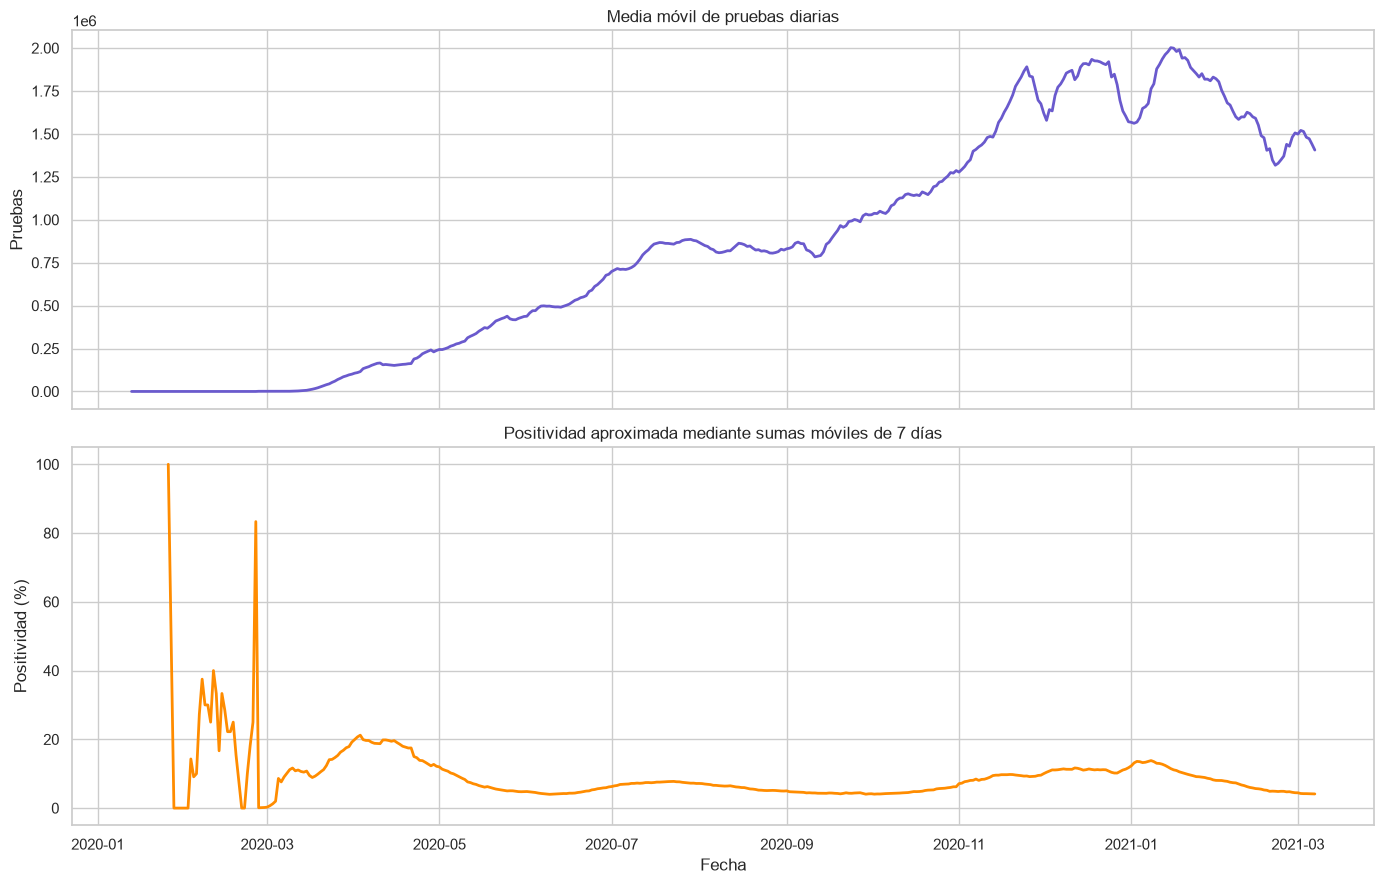

In [30]:
evolucion_nacional["casos_7d_suma"] = (
    evolucion_nacional["nuevos_casos"]
    .rolling(7, min_periods=7)
    .sum()
)
evolucion_nacional["pruebas_7d_suma"] = (
    evolucion_nacional["nuevas_pruebas"]
    .rolling(7, min_periods=7)
    .sum()
)
evolucion_nacional["positividad_7d"] = (
    evolucion_nacional["casos_7d_suma"]
    / evolucion_nacional["pruebas_7d_suma"]
    * 100
)

positividad_valida = evolucion_nacional[
    evolucion_nacional["positividad_7d"].between(0, 100)
].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(
    evolucion_nacional["date"],
    evolucion_nacional["nuevas_pruebas"].rolling(7, min_periods=1).mean(),
    color="slateblue",
    linewidth=2,
)
axes[0].set_title("Media móvil de pruebas diarias")
axes[0].set_ylabel("Pruebas")

axes[1].plot(
    positividad_valida["date"],
    positividad_valida["positividad_7d"],
    color="darkorange",
    linewidth=2,
)
axes[1].set_title("Positividad aproximada mediante sumas móviles de 7 días")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Positividad (%)")

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "pruebas_positividad.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Interpretación

El número de pruebas aumentó de forma sostenida durante 2020. La positividad
volvió a elevarse durante las grandes olas, indicando que el crecimiento de
casos no se explica únicamente por una mayor capacidad de diagnóstico.

La positividad es aproximada porque los estados no utilizaron siempre la misma
definición de prueba o persona examinada.

## 14. Análisis bivariante y multivariante

Estudiamos las relaciones entre los principales indicadores nacionales. Las
correlaciones describen asociación, pero no demuestran causalidad.

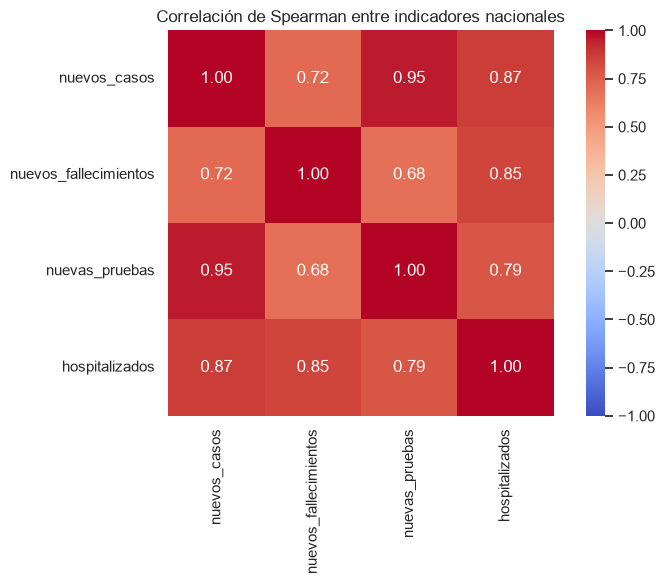

,nuevos_casos,nuevos_fallecimientos,nuevas_pruebas,hospitalizados
nuevos_casos,1.000000,0.715813,0.954399,0.867304
nuevos_fallecimientos,0.715813,1.000000,0.684225,0.848549
nuevas_pruebas,0.954399,0.684225,1.000000,0.788447
hospitalizados,0.867304,0.848549,0.788447,1.000000


In [31]:
variables_correlacion = [
    "nuevos_casos",
    "nuevos_fallecimientos",
    "nuevas_pruebas",
    "hospitalizados",
]

correlaciones = (
    evolucion_nacional[variables_correlacion]
    .corr(method="spearman")
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    correlaciones,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True,
    ax=ax,
)
ax.set_title("Correlación de Spearman entre indicadores nacionales")

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "matriz_correlacion.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

correlaciones

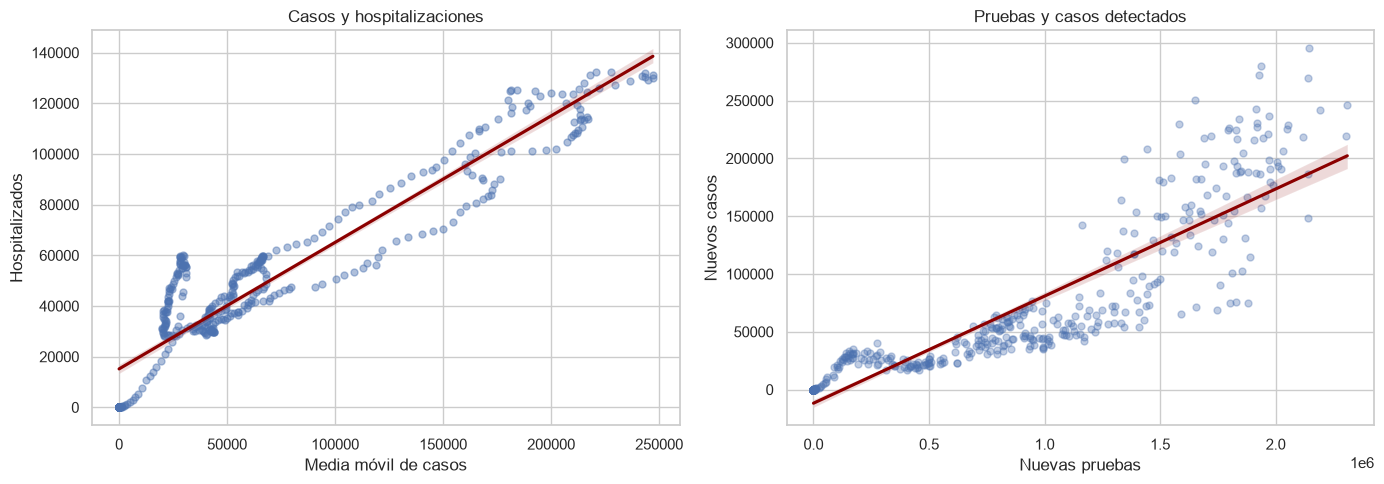

In [32]:
datos_relacion = evolucion_nacional.dropna(
    subset=["media_7d_casos", "hospitalizados"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=datos_relacion,
    x="media_7d_casos",
    y="hospitalizados",
    scatter_kws={"alpha": 0.45, "s": 25},
    line_kws={"color": "darkred"},
    ax=axes[0],
)
axes[0].set_title("Casos y hospitalizaciones")
axes[0].set_xlabel("Media móvil de casos")
axes[0].set_ylabel("Hospitalizados")

sns.regplot(
    data=evolucion_nacional,
    x="nuevas_pruebas",
    y="nuevos_casos",
    scatter_kws={"alpha": 0.35, "s": 25},
    line_kws={"color": "darkred"},
    ax=axes[1],
)
axes[1].set_title("Pruebas y casos detectados")
axes[1].set_xlabel("Nuevas pruebas")
axes[1].set_ylabel("Nuevos casos")

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "relaciones_bivariantes.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Relación temporal entre casos y fallecimientos

Los fallecimientos suelen reflejar contagios ocurridos días o semanas antes.
Calculamos la correlación entre casos actuales y fallecimientos desplazados
entre 0 y 28 días para identificar el desfase con mayor asociación estadística.

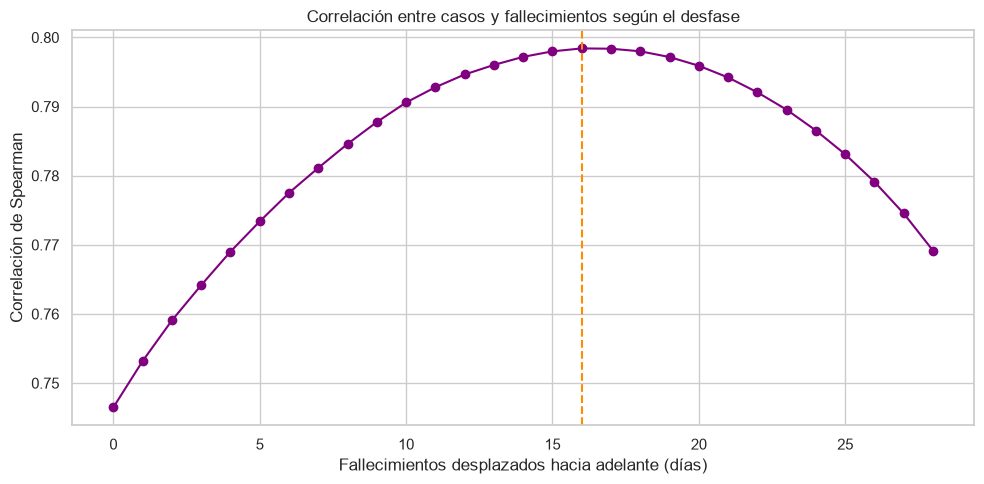

Desfase con mayor correlación: 16 días
Correlación: 0.798


In [33]:
correlacion_por_desfase = []

for dias in range(29):
    correlacion = (
        evolucion_nacional["media_7d_casos"]
        .corr(
            evolucion_nacional["media_7d_fallecimientos"].shift(-dias),
            method="spearman",
        )
    )
    correlacion_por_desfase.append({
        "desfase_dias": dias,
        "correlacion": correlacion,
    })

correlacion_desfase = pd.DataFrame(correlacion_por_desfase)
mejor_desfase = correlacion_desfase.loc[
    correlacion_desfase["correlacion"].idxmax()
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    correlacion_desfase["desfase_dias"],
    correlacion_desfase["correlacion"],
    marker="o",
    color="purple",
)
ax.axvline(
    mejor_desfase["desfase_dias"],
    color="darkorange",
    linestyle="--",
)
ax.set_title("Correlación entre casos y fallecimientos según el desfase")
ax.set_xlabel("Fallecimientos desplazados hacia adelante (días)")
ax.set_ylabel("Correlación de Spearman")

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "correlacion_desfase_casos_muertes.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(f"Desfase con mayor correlación: {mejor_desfase['desfase_dias']:.0f} días")
print(f"Correlación: {mejor_desfase['correlacion']:.3f}")

### Interpretación multivariante

La relación entre casos, hospitalizaciones y fallecimientos es positiva, pero
está condicionada por el tiempo. El desfase de mayor correlación ofrece una
aproximación descriptiva de cuándo la curva de fallecimientos sigue a la de
casos; no representa por sí solo un tiempo clínico individual.

## 15. Comparación territorial ajustada por población

Los rankings absolutos favorecen a los estados más poblados. Incorporamos la
población del Censo de 2020 para calcular casos y fallecimientos acumulados por
cada 100.000 habitantes.

In [34]:
poblacion_2020 = {
    "AL": 5024279, "AK": 733391, "AZ": 7151502, "AR": 3011524,
    "CA": 39538223, "CO": 5773714, "CT": 3605944, "DE": 989948,
    "DC": 689545, "FL": 21538187, "GA": 10711908, "HI": 1455271,
    "ID": 1839106, "IL": 12812508, "IN": 6785528, "IA": 3190369,
    "KS": 2937880, "KY": 4505836, "LA": 4657757, "ME": 1362359,
    "MD": 6177224, "MA": 7029917, "MI": 10077331, "MN": 5706494,
    "MS": 2961279, "MO": 6154913, "MT": 1084225, "NE": 1961504,
    "NV": 3104614, "NH": 1377529, "NJ": 9288994, "NM": 2117522,
    "NY": 20201249, "NC": 10439388, "ND": 779094, "OH": 11799448,
    "OK": 3959353, "OR": 4237256, "PA": 13002700, "RI": 1097379,
    "SC": 5118425, "SD": 886667, "TN": 6910840, "TX": 29145505,
    "UT": 3271616, "VT": 643077, "VA": 8631393, "WA": 7705281,
    "WV": 1793716, "WI": 5893718, "WY": 576851,
}

comparacion_estados = ultimo_registro.copy()
comparacion_estados["poblacion_2020"] = (
    comparacion_estados["state"].map(poblacion_2020)
)
comparacion_estados["casos_100k"] = (
    comparacion_estados["positive"]
    / comparacion_estados["poblacion_2020"]
    * 100_000
)
comparacion_estados["muertes_100k"] = (
    comparacion_estados["death"]
    / comparacion_estados["poblacion_2020"]
    * 100_000
)

comparacion_estados[
    ["state", "positive", "death", "casos_100k", "muertes_100k"]
].head()

,state,positive,death,casos_100k,muertes_100k
8526,MD,387319.0,7955.0,6270.114213,128.779529
12577,NH,76861.0,1184.0,5579.628451,85.951004
11821,ND,100391.0,1478.0,12885.608155,189.707532
14444,OH,978471.0,17656.0,8292.515040,149.634118
9264,MI,656072.0,16658.0,6510.374622,165.301705


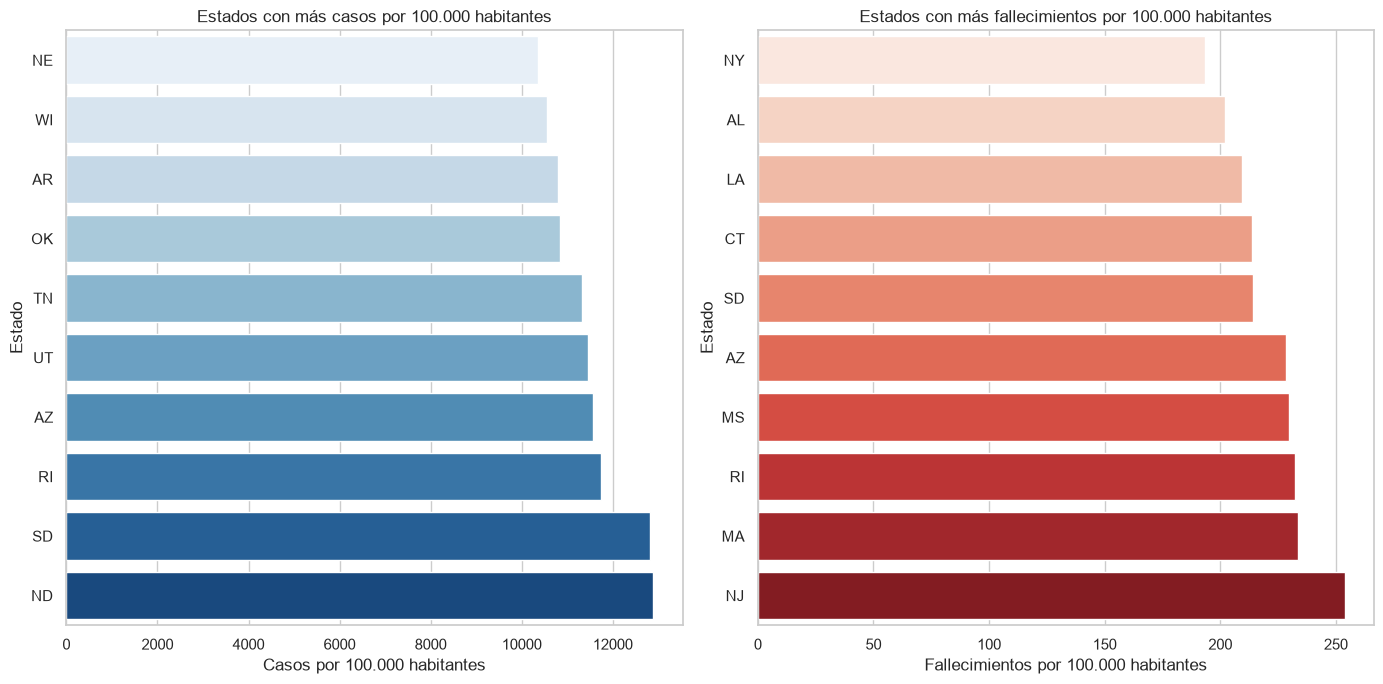

In [35]:
top_casos_100k = (
    comparacion_estados.nlargest(10, "casos_100k")
    .sort_values("casos_100k")
)
top_muertes_100k = (
    comparacion_estados.nlargest(10, "muertes_100k")
    .sort_values("muertes_100k")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sns.barplot(
    data=top_casos_100k,
    x="casos_100k",
    y="state",
    hue="state",
    palette="Blues",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Estados con más casos por 100.000 habitantes")
axes[0].set_xlabel("Casos por 100.000 habitantes")
axes[0].set_ylabel("Estado")

sns.barplot(
    data=top_muertes_100k,
    x="muertes_100k",
    y="state",
    hue="state",
    palette="Reds",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Estados con más fallecimientos por 100.000 habitantes")
axes[1].set_xlabel("Fallecimientos por 100.000 habitantes")
axes[1].set_ylabel("Estado")

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "ranking_estados_por_100k.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Hallazgo territorial

El ranking por población cambia de forma sustancial respecto al ranking
absoluto. Los estados con mayor volumen no son necesariamente los que
experimentaron la mayor carga relativa. Para la toma de decisiones territoriales
deben priorizarse las tasas por habitante.

## 16. Evolución de los estados con mayor volumen

Comparamos la media móvil de casos diarios de los cinco estados con más casos
acumulados para observar si sus picos ocurrieron al mismo tiempo.

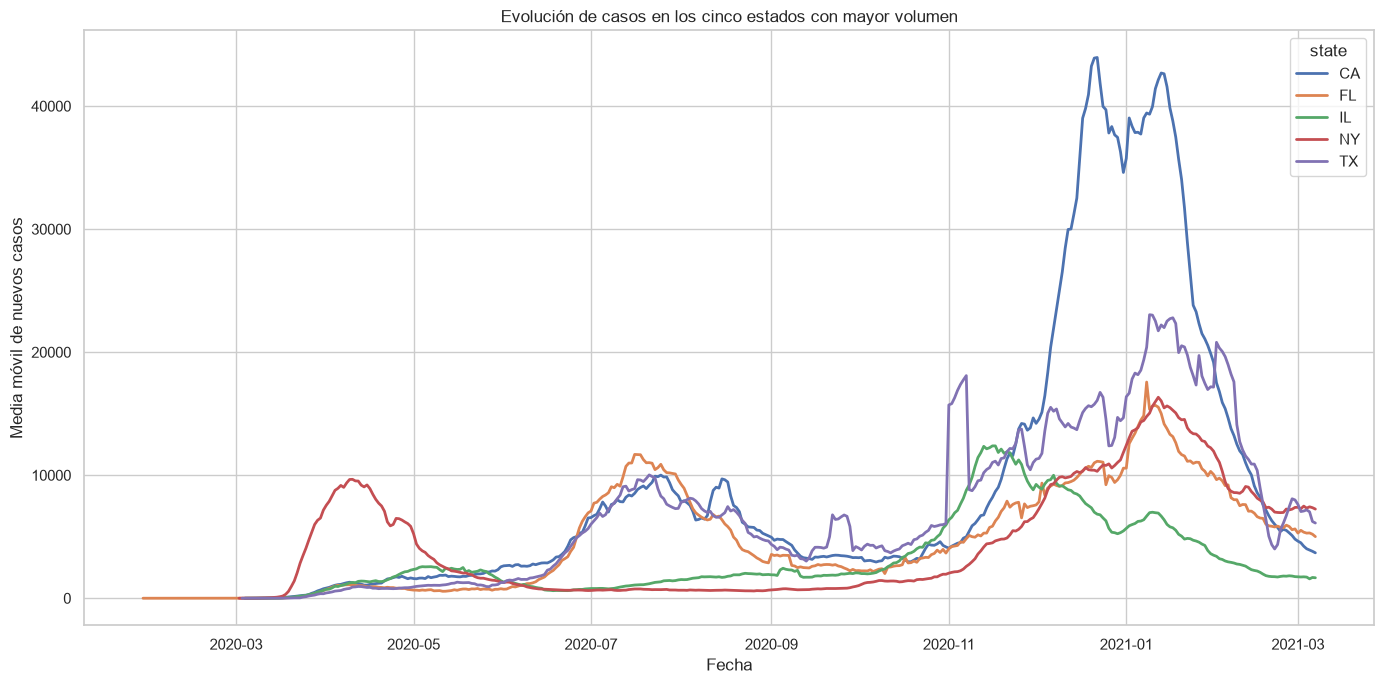

In [36]:
estados_top_5 = (
    ultimo_registro.nlargest(5, "positive")["state"].tolist()
)

evolucion_estados = (
    df_clean[df_clean["state"].isin(estados_top_5)]
    .sort_values(["state", "date"])
    .copy()
)
evolucion_estados["media_7d_casos"] = (
    evolucion_estados.groupby("state")["positiveIncrease"]
    .transform(lambda serie: serie.rolling(7, min_periods=1).mean())
)

fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=evolucion_estados,
    x="date",
    y="media_7d_casos",
    hue="state",
    linewidth=2,
    ax=ax,
)
ax.set_title("Evolución de casos en los cinco estados con mayor volumen")
ax.set_xlabel("Fecha")
ax.set_ylabel("Media móvil de nuevos casos")

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "evolucion_top_5_estados.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Interpretación

Las curvas estatales no evolucionan de forma idéntica. Aunque la ola invernal
afecta a todos los grandes estados, los repuntes previos aparecen en momentos
y con intensidades diferentes. La cifra nacional oculta esta heterogeneidad.

## 17. Síntesis ampliada de hallazgos

1. La ola invernal de 2020-2021 fue el periodo de máxima presión conjunta sobre
   contagios, hospitalizaciones y mortalidad.
2. Las distribuciones diarias son asimétricas y contienen valores extremos
   epidemiológicos y administrativos que no deben eliminarse sin revisión.
3. La cobertura es alta para casos, fallecimientos y pruebas, pero insuficiente
   para realizar comparaciones generales de UCI y ventilación.
4. El aumento de casos durante las grandes olas estuvo acompañado por un
   incremento de positividad, no solamente por una mayor realización de pruebas.
5. Casos, hospitalizaciones y fallecimientos presentan asociaciones positivas,
   con un desfase temporal entre la curva de casos y la de mortalidad.
6. Los rankings absolutos están dominados por estados grandes; las tasas por
   100.000 habitantes ofrecen una lectura territorial más justa.
7. Los estados no atravesaron las olas con la misma sincronía ni intensidad.

## 18. Conclusiones ejecutivas

1. **La ola m?s cr?tica se produjo durante el invierno de 2020-2021.**  
   Las hospitalizaciones alcanzaron su m?ximo el 6 de enero de 2021, los casos el 11 de enero y los fallecimientos el 13 de enero.

2. **El pico nacional super? los 247.000 casos diarios.**  
   La media m?vil de siete d?as alcanz? aproximadamente 247.111 nuevos casos diarios.

3. **La presi?n hospitalaria fue especialmente elevada.**  
   Se registr? un m?ximo de 132.474 personas hospitalizadas, con 53 de las 56 jurisdicciones reportando informaci?n ese d?a.

4. **Los casos anticipan estad?sticamente la curva de mortalidad.**  
   La mayor correlaci?n de Spearman se observa con un desfase aproximado de 16 d?as (0,798). Es una asociaci?n agregada y no un tiempo cl?nico individual.

5. **El volumen absoluto y la carga relativa cuentan historias diferentes.**  
   California y Texas lideran los totales, pero el ranking cambia al calcular casos y fallecimientos por 100.000 habitantes.

6. **El aumento de casos no se explica ?nicamente por el aumento de pruebas.**  
   La positividad aproximada tambi?n creci? durante las principales olas, especialmente durante el invierno.

7. **La calidad de los datos no es uniforme.**  
   Casos, fallecimientos y pruebas presentan alta cobertura; UCI, ventilaci?n y algunas pruebas espec?ficas no permiten comparaciones generales fiables.

8. **Las correcciones administrativas deben conservarse y documentarse.**  
   Se identificaron 141 registros con incrementos negativos en casos, fallecimientos o pruebas, mantenidos para garantizar la trazabilidad.

## 19. Limitaciones

- El periodo termina el 7 de marzo de 2021, por lo que no representa toda la evoluci?n posterior de la pandemia.
- Los criterios, definiciones y ritmos de notificaci?n variaron entre jurisdicciones.
- Las tasas por 100.000 habitantes utilizan la poblaci?n del Censo de 2020 y no ajustan por edad, densidad u otras diferencias demogr?ficas.
- Los datos de hospitalizaci?n no tienen cobertura completa, especialmente al inicio del periodo.
- La positividad calculada es aproximada porque los estados no reportaron las pruebas de forma completamente homog?nea.
- Los incrementos diarios contienen correcciones retrospectivas que pueden generar valores negativos.
- Las correlaciones y asociaciones temporales no demuestran causalidad ni representan trayectorias cl?nicas individuales.